In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import contextily as ctx
import numpy as np

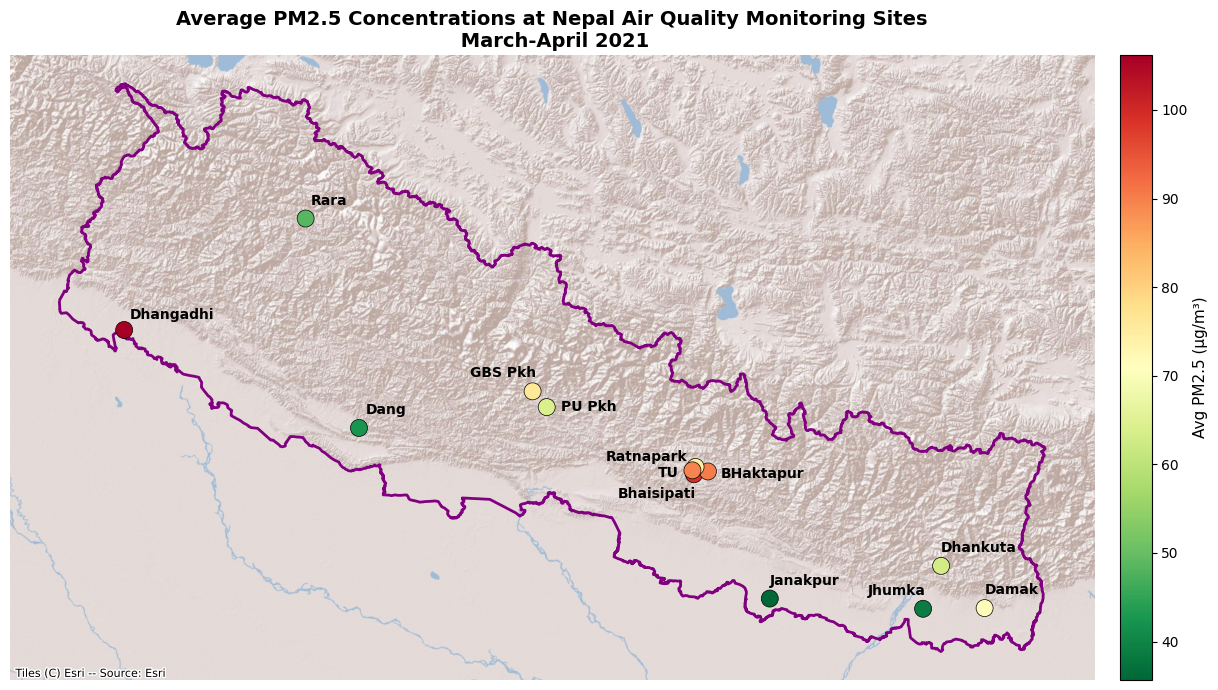

In [ ]:
xl = pd.ExcelFile("DOE_Nepal_2021.xlsx")
records = []

for sheet in xl.sheet_names: 
    df = pd.read_excel(xl, sheet_name=sheet)
    df.columns = ['date', 'pm25', 'pm10', 'tsp', 'lat', 'lon'] #renaming the columns 
    
    df['date'] = pd.to_datetime(df['date'])
    mask = (df['date'].dt.month >= 3) & (df['date'].dt.month <= 4)
    sub = df[mask] 

    records.append({
        'station': sheet,
        'lat': df['lat'].dropna().iloc[0],
        'lon': df['lon'].dropna().iloc[0],
        'avg_pm25': sub['pm25'].mean() #
    })

df_stations = pd.DataFrame(records)
df_stations = df_stations[~df_stations['station'].isin(['Biratnagar', 'SImara', 'Nepalgunj', 'Bhimdatta'])] 


gdf_stations = gpd.GeoDataFrame(
    df_stations,
    geometry = gpd.points_from_xy(df_stations.lon, df_stations.lat), 
    crs = "EPSG:4326" 
).to_crs(epsg = 3857) 

#loads Nepal boundary
shapeFile = 'nepal-standard-shapefiles-master/shapefiles/nepal_bnd_wgs84.shp'
gdf = gpd.read_file(shapeFile)
nepal = gdf.dissolve() 
nepal_wm = nepal.to_crs(epsg=3857)

#plot
fig, ax = plt.subplots(figsize=(14, 7)) 
nepal_wm.boundary.plot(ax=ax, edgecolor='purple', linewidth=2) 
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=9) 

cmap = cm.RdYlGn_r #red = high, green = low
norm = mcolors.Normalize(
    vmin=gdf_stations['avg_pm25'].min(),
    vmax=gdf_stations['avg_pm25'].max()
)

sc = ax.scatter(
    gdf_stations.geometry.x,
    gdf_stations.geometry.y,
    c = gdf_stations['avg_pm25'],
    cmap = cmap,
    norm = norm,
    s = 150, #dot size
    zorder = 5, #draws dots on top of everything else
    edgecolors = 'black',
    linewidths = 0.5
)

offsets = {
    'Ratnapark':  (-65, 4),
    'TU':         (-25, -5),
    'BHaktapur':  (9, -5),
    'Bhaisipati': (-55, -17),
    'GBS Pkh':    (-45, 10),
    'PU Pkh':     (10, -3),
    'Jhumka':     (-40, 10),
    'Damak':      (0, 10),
    'Dhankuta':   (0, 10),
    'Janakpur':   (0, 10),
    'Dang':       (5, 10),
    'Dhangadhi':  (4, 8),
    'Rara':       (4, 10),
}

for idx, row in gdf_stations.iterrows():
    ax.annotate(
        row['station'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=offsets.get(row['station']),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

#key
cbar = plt.colorbar(sc, ax = ax, fraction = 0.025, pad = 0.02)
cbar.set_label('Avg PM2.5 (µg/m³)', fontsize = 11)

ax.set_axis_off() 
plt.title("Average PM2.5 Concentrations at Nepal Air Quality Monitoring Sites\n March-April 2021", fontsize=14, fontweight='bold')
plt.tight_layout() #auto layout
plt.show()